In [1]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [2]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [3]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [33]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2494


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""16/07/2025""","""1212""","""36 22 37 11 07 01""","""24""","""19""","""Promoción Sí o Sí""","""010711223637""","[1, 7, … 37]",1,7,11,22,36,37,"""01""","""07""","""11""","""22""","""36""","""37""",null,null,null,null,null,null,false,0,"""06_04_11_14_01""",1,"""3""","""2""","""4""","""6""","""4""","""11""","""14""","""1""","""36""","""2"""
"""13/07/2025""","""1211""","""09 32 43 49 38 24""","""05""","""35 30""","""Promoción Sí o Sí""","""092432384349""","[9, 24, … 49]",9,24,32,38,43,49,"""09""","""24""","""32""","""38""","""43""","""49""","""01""","""07""","""11""","""22""","""36""","""37""",true,16,"""15_08_06_05_06""",5,"""1""","""3""","""3""","""15""","""8""","""6""","""5""","""6""","""40""","""1"""
"""09/07/2025""","""1210""","""35 28 09 42 31 16""","""45""","""50 23""","""Promoción Sí o Sí""","""091628313542""","[9, 16, … 42]",9,16,28,31,35,42,"""09""","""16""","""28""","""31""","""35""","""42""","""09""","""24""","""32""","""38""","""43""","""49""",false,0,"""07_12_03_04_07""",-32,"""1""","""3""","""3""","""7""","""12""","""3""","""4""","""7""","""33""","""1"""
"""06/07/2025""","""1209""","""29 20 14 11 03 15""","""35""","""12 33 37""","""Promoción Sí o Sí""","""031114152029""","[3, 11, … 29]",3,11,14,15,20,29,"""03""","""11""","""14""","""15""","""20""","""29""","""09""","""16""","""28""","""31""","""35""","""42""",false,0,"""08_03_01_05_09""",-9,"""3""","""2""","""4""","""8""","""3""","""1""","""5""","""9""","""26""","""0"""
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1"""
"""29/06/2025""","""1207""","""47 37 32 22 24 23""","""04""","""20 39 09""","""Promoción Sí o Sí""","""222324323747""","[22, 23, … 47]",22,23,24,32,37,47,"""22""","""23""","""24""","""32""","""37""","""47""","""07""","""10""","""14""","""28""","""29""","""32""",true,24,"""01_01_08_05_10""",35,"""3""","""3""","""3""","""1""","""1""","""8""","""5""","""10""","""25""","""1"""
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2"""
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2"""
"""18/06/2025""","""1204""","""26 45 28 09 24 50""","""14""","""07""","""Promoción Sí o Sí""","""092426284550""","[9, 24, … 50]",9,24,26,28,45,50,"""09""","""24""","""26""","""28""","""45""","""50""","""02""","""07""","""25""","""33""","""45""","""46""",true,24,"""15_02_02_17_05""",-44,"""0""","""4""","""2""","""15""","""2""","""2""","""17""","""5""","""41""","""2"""


In [36]:

def count_column (col_name: str) -> None:
  df_viz = dfRows \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

# count_column('j1')
count_column("jsum")
count_column("joor")
count_column('primes_count')
count_column('evens_count')
count_column('odds_count')

jsums = count_column('jsum')
# print(jsums[0:22])



:Bars   [jsum]   (count)

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [6]:
dfRows.item(0, 'b2')

7

In [7]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [8]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='01'
df_viz FOR str_b1 = 01


post_str_b1,count,percent
str,u32,f64
"""01""",58,17.109145
"""02""",43,12.684366
"""05""",31,9.144543
"""03""",28,8.259587
"""06""",22,6.489676
…,…,…
"""17""",2,0.589971
"""25""",1,0.294985
"""28""",1,0.294985


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 01
Last 3 results last_results=['05', '22', '02']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""04/06/2025""","""1200""","""01 36 50 30 05 21""","""37""","""09 24 43""","""Promoción Sí o Sí""","""010521303650""","[1, 5, … 50]",1,5,21,30,36,50,"""01""","""05""","""21""","""30""","""36""","""50""","""05""","""08""","""12""","""18""","""25""","""34""",false,0,"""04_16_09_06_14""",-16,"""1""","""3""","""3""","""4""","""16""","""9""","""6""","""14""","""49"""
"""25/05/2025""","""1197""","""21 31 01 09 04 08""","""25""","""35 41 24""","""Promoción Sí o Sí""","""010408092131""","[1, 4, … 31]",1,4,8,9,21,31,"""01""","""04""","""08""","""09""","""21""","""31""","""02""","""04""","""09""","""15""","""16""","""50""",false,0,"""03_04_01_12_10""",-45,"""1""","""2""","""4""","""3""","""4""","""1""","""12""","""10""","""30"""
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48"""
"""26/03/2025""","""1180""","""43 01 05 37 35 13""","""39""","""38 07 45 16""","""Promoción Sí o Sí""","""010513353743""","[1, 5, … 43]",1,5,13,35,37,43,"""01""","""05""","""13""","""35""","""37""","""43""","""25""","""28""","""29""","""31""","""46""","""47""",true,19,"""04_08_22_02_06""",102,"""4""","""0""","""6""","""4""","""8""","""22""","""2""","""6""","""42"""
"""09/03/2025""","""1175""","""01 42 44 20 38 23""","""14""","""35 36 34 45 41""","""Promoción Sí o Sí""","""012023384244""","[1, 20, … 44]",1,20,23,38,42,44,"""01""","""20""","""23""","""38""","""42""","""44""","""07""","""16""","""17""","""32""","""34""","""44""",false,0,"""19_03_15_04_02""",83,"""1""","""4""","""2""","""19""","""3""","""15""","""4""","""2""","""43"""
"""05/03/2025""","""1174""","""01 32 03 12 28 47""","""20""","""49 06 23 24""","""Promoción Sí o Sí""","""010312283247""","[1, 3, … 47]",1,3,12,28,32,47,"""01""","""03""","""12""","""28""","""32""","""47""","""01""","""20""","""23""","""38""","""42""","""44""",false,0,"""02_09_16_04_15""",61,"""2""","""3""","""3""","""2""","""9""","""16""","""4""","""15""","""46"""
"""19/01/2025""","""1161""","""23 44 45 05 02 01""","""16""","""24 19""","""Promoción Sí o Sí""","""010205234445""","[1, 2, … 45]",1,2,5,23,44,45,"""01""","""02""","""05""","""23""","""44""","""45""","""06""","""10""","""21""","""31""","""32""","""49""",false,0,"""01_03_18_21_01""",14,"""3""","""2""","""4""","""1""","""3""","""18""","""21""","""1""","""44"""
"""22/12/2024""","""1153""","""17 02 49 40 24 01""","""45""","""14 22 05""","""Promoción Sí o Sí""","""010217244049""","[1, 2, … 49]",1,2,17,24,40,49,"""01""","""02""","""17""","""24""","""40""","""49""","""02""","""05""","""14""","""15""","""24""","""39""",true,16,"""01_15_07_16_09""",-72,"""2""","""3""","""3""","""1""","""15""","""7""","""16""","""9""","""48"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45"""


df_jumps_map FOR str_b1 = 01


jumps_map,count
str,u32
"""10_03_09_04_10""",1
"""03_10_03_21_07""",1
"""04_08_01_06_05""",1
"""10_09_16_01_01""",1
"""01_11_08_01_11""",1
…,…
"""05_03_02_03_29""",1
"""10_05_01_04_22""",1
"""03_07_05_07_06""",1


df_unijump FOR str_b1 = 01


unijump,count
i64,u32
-20,10
-16,7
1,7
-32,6
-26,6
…,…
-60,1
72,1
123,1


In [9]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='07'
df_viz FOR str_b2 = 07


post_str_b2,count,percent
str,u32,f64
"""05""",11,9.322034
"""10""",10,8.474576
"""03""",8,6.779661
"""11""",7,5.932203
"""07""",7,5.932203
…,…,…
"""26""",3,2.542373
"""25""",3,2.542373
"""18""",3,2.542373


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 07
Last 3 results last_results=['14', '05', '11']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44"""
"""14/05/2025""","""1194""","""38 07 12 13 04 09""","""42""","""46 28""","""Promoción Sí o Sí""","""040709121338""","[4, 7, … 38]",4,7,9,12,13,38,"""04""","""07""","""09""","""12""","""13""","""38""","""09""","""11""","""13""","""15""","""33""","""42""",false,0,"""03_02_03_01_25""",34,"""2""","""3""","""3""","""3""","""2""","""3""","""1""","""25""","""34"""
"""23/03/2025""","""1179""","""24 07 18 03 37 49""","""43""","""50 28""","""Promoción Sí o Sí""","""030718243749""","[3, 7, … 49]",3,7,18,24,37,49,"""03""","""07""","""18""","""24""","""37""","""49""","""01""","""05""","""13""","""35""","""37""","""43""",false,0,"""04_11_06_13_12""",-44,"""3""","""2""","""4""","""4""","""11""","""6""","""13""","""12""","""46"""
"""11/09/2024""","""1124""","""04 41 07 28 29 46""","""20""","""11""","""Promoción Sí o Sí""","""040728294146""","[4, 7, … 46]",4,7,28,29,41,46,"""04""","""07""","""28""","""29""","""41""","""46""","""01""","""03""","""29""","""36""","""38""","""43""",true,16,"""03_21_01_12_05""",-118,"""3""","""3""","""3""","""3""","""21""","""1""","""12""","""5""","""42"""
"""09/06/2024""","""1097""","""39 20 29 03 07 11""","""27""","""21 08""","""Promoción Sí o Sí""","""030711202939""","[3, 7, … 39]",3,7,11,20,29,39,"""03""","""07""","""11""","""20""","""29""","""39""","""03""","""08""","""11""","""16""","""32""","""48""",true,9,"""04_04_09_09_10""",16,"""4""","""1""","""5""","""4""","""4""","""9""","""9""","""10""","""36"""
"""14/04/2024""","""1081""","""05 17 07 47 41 19""","""04""","""33 03""","""Promoción Sí o Sí""","""050717194147""","[5, 7, … 47]",5,7,17,19,41,47,"""05""","""07""","""17""","""19""","""41""","""47""","""06""","""21""","""26""","""27""","""40""","""47""",true,19,"""02_10_02_22_06""",-108,"""6""","""0""","""6""","""2""","""10""","""2""","""22""","""6""","""42"""
"""03/04/2024""","""1078""","""02 07 38 18 31 26""","""17""","""41 03""","""Promoción Sí o Sí""","""020718263138""","[2, 7, … 38]",2,7,18,26,31,38,"""02""","""07""","""18""","""26""","""31""","""38""","""05""","""10""","""20""","""22""","""25""","""35""",false,0,"""05_11_08_05_07""",-4,"""3""","""4""","""2""","""5""","""11""","""8""","""5""","""7""","""36"""
"""06/03/2024""","""1070""","""30 22 04 07 39 37""","""38""","""43 02 18""","""Promoción Sí o Sí""","""040722303739""","[4, 7, … 39]",4,7,22,30,37,39,"""04""","""07""","""22""","""30""","""37""","""39""","""12""","""18""","""30""","""32""","""34""","""35""",true,16,"""03_15_08_07_02""",-35,"""2""","""3""","""3""","""3""","""15""","""8""","""7""","""2""","""35"""
"""14/02/2024""","""1064""","""42 03 18 07 29 39""","""30""","""28 31""","""Promoción Sí o Sí""","""030718293942""","[3, 7, … 42]",3,7,18,29,39,42,"""03""","""07""","""18""","""29""","""39""","""42""","""12""","""23""","""24""","""31""","""35""","""42""",true,8,"""04_11_11_10_03""",-11,"""3""","""2""","""4""","""4""","""11""","""11""","""10""","""3""","""39"""


df_jumps_map FOR str_b2 = 07


jumps_map,count
str,u32
"""01_04_05_23_05""",2
"""03_04_01_12_17""",1
"""01_03_13_15_05""",1
"""03_05_15_02_03""",1
"""01_02_04_15_13""",1
…,…
"""01_02_01_06_23""",1
"""02_03_04_11_05""",1
"""02_05_03_07_04""",1


df_unijump FOR str_b2 = 07


unijump,count
i64,u32
16,4
-64,3
34,2
12,2
-2,2
…,…
129,1
-13,1
15,1


In [10]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='11'
df_viz FOR str_b3 = 11


post_str_b3,count,percent
str,u32,f64
"""26""",8,8.602151
"""14""",6,6.451613
"""17""",5,5.376344
"""19""",5,5.376344
"""10""",5,5.376344
…,…,…
"""35""",1,1.075269
"""07""",1,1.075269
"""08""",1,1.075269


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 11
Last 3 results last_results=['20', '15', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""30/04/2025""","""1190""","""11 36 33 06 02 16""","""37""","""14 07 10 01""","""Promoción Sí o Sí""","""020611163336""","[2, 6, … 36]",2,6,11,16,33,36,"""02""","""06""","""11""","""16""","""33""","""36""","""09""","""10""","""15""","""19""","""35""","""37""",true,8,"""04_05_05_17_03""",-51,"""2""","""4""","""2""","""4""","""5""","""5""","""17""","""3""","""34"""
"""20/04/2025""","""1187""","""33 02 06 42 34 11""","""37""","""49 20""","""Promoción Sí o Sí""","""020611333442""","[2, 6, … 42]",2,6,11,33,34,42,"""02""","""06""","""11""","""33""","""34""","""42""","""09""","""16""","""20""","""22""","""33""","""35""",false,0,"""04_05_22_01_08""",120,"""2""","""4""","""2""","""4""","""5""","""22""","""1""","""8""","""40"""
"""28/08/2024""","""1120""","""11 37 46 47 06 03""","""29""","""14 09 05 40""","""Promoción Sí o Sí""","""030611374647""","[3, 6, … 47]",3,6,11,37,46,47,"""03""","""06""","""11""","""37""","""46""","""47""","""04""","""19""","""23""","""37""","""41""","""50""",true,17,"""03_05_26_09_01""",104,"""4""","""2""","""4""","""3""","""5""","""26""","""9""","""1""","""44"""
"""12/06/2024""","""1098""","""03 11 48 08 32 16""","""09""","""23""","""Promoción Sí o Sí""","""030811163248""","[3, 8, … 48]",3,8,11,16,32,48,"""03""","""08""","""11""","""16""","""32""","""48""","""02""","""08""","""19""","""21""","""23""","""46""",true,8,"""05_03_05_16_16""",-25,"""2""","""4""","""2""","""5""","""3""","""5""","""16""","""16""","""45"""
"""09/06/2024""","""1097""","""39 20 29 03 07 11""","""27""","""21 08""","""Promoción Sí o Sí""","""030711202939""","[3, 7, … 39]",3,7,11,20,29,39,"""03""","""07""","""11""","""20""","""29""","""39""","""03""","""08""","""11""","""16""","""32""","""48""",true,9,"""04_04_09_09_10""",16,"""4""","""1""","""5""","""4""","""4""","""9""","""9""","""10""","""36"""
"""20/03/2024""","""1074""","""22 08 31 11 10 21""","""06""","""16 43""","""Promoción Sí o Sí""","""081011212231""","[8, 10, … 31]",8,10,11,21,22,31,"""08""","""10""","""11""","""21""","""22""","""31""","""09""","""21""","""25""","""28""","""32""","""48""",false,0,"""02_01_10_01_09""",63,"""2""","""3""","""3""","""2""","""1""","""10""","""1""","""9""","""23"""
"""10/01/2024""","""1054""","""29 01 11 10 36 30""","""31""","""38 23 20 40""","""Promoción Sí o Sí""","""011011293036""","[1, 10, … 36]",1,10,11,29,30,36,"""01""","""10""","""11""","""29""","""30""","""36""","""20""","""27""","""28""","""41""","""44""","""47""",false,0,"""09_01_18_01_06""",115,"""2""","""3""","""3""","""9""","""1""","""18""","""1""","""6""","""35"""
"""20/12/2023""","""1048""","""44 07 09 27 21 11""","""47""","""03 17""","""Promoción Sí o Sí""","""070911212744""","[7, 9, … 44]",7,9,11,21,27,44,"""07""","""09""","""11""","""21""","""27""","""44""","""08""","""25""","""29""","""35""","""36""","""42""",true,24,"""02_02_10_06_17""",47,"""2""","""1""","""5""","""2""","""2""","""10""","""6""","""17""","""37"""
"""17/12/2023""","""1047""","""05 22 11 17 38 10""","""14""","""07 41 16""","""Promoción Sí o Sí""","""051011172238""","[5, 10, … 38]",5,10,11,17,22,38,"""05""","""10""","""11""","""17""","""22""","""38""","""07""","""09""","""11""","""21""","""27""","""44""",false,0,"""05_01_06_05_16""",33,"""3""","""3""","""3""","""5""","""1""","""6""","""5""","""16""","""33"""


df_jumps_map FOR str_b3 = 11


jumps_map,count
str,u32
"""01_04_05_23_05""",2
"""03_01_03_07_22""",1
"""06_02_05_03_14""",1
"""05_03_03_03_03""",1
"""01_08_04_10_12""",1
…,…
"""01_09_03_04_01""",1
"""03_04_01_12_17""",1
"""07_03_01_03_21""",1


df_unijump FOR str_b3 = 11


unijump,count
i64,u32
-24,4
-17,2
48,2
29,2
-27,2
…,…
74,1
57,1
-88,1


In [11]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='22'
df_viz FOR str_b4 = 22


post_str_b4,count,percent
str,u32,f64
"""31""",9,7.826087
"""26""",7,6.086957
"""34""",7,6.086957
"""20""",6,5.217391
"""27""",6,5.217391
…,…,…
"""42""",1,0.869565
"""10""",1,0.869565
"""40""",1,0.869565


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 22
Last 3 results last_results=['31', '41', '33']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""11/06/2025""","""1202""","""22 39 20 19 38 15""","""32""","""13 35 25""","""Promoción Sí o Sí""","""151920223839""","[15, 19, … 39]",15,19,20,22,38,39,"""15""","""19""","""20""","""22""","""38""","""39""","""24""","""29""","""34""","""41""","""42""","""44""",false,0,"""04_01_02_16_01""",-51,"""1""","""3""","""3""","""4""","""1""","""2""","""16""","""1""","""24"""
"""23/04/2025""","""1188""","""22 16 20 33 35 09""","""46""","""24""","""Promoción Sí o Sí""","""091620223335""","[9, 16, … 35]",9,16,20,22,33,35,"""09""","""16""","""20""","""22""","""33""","""35""","""07""","""08""","""21""","""33""","""41""","""46""",false,0,"""07_04_02_11_02""",-39,"""0""","""3""","""3""","""7""","""4""","""2""","""11""","""2""","""26"""
"""16/02/2025""","""1169""","""16 22 34 11 06 45""","""26""","""39 50""","""Promoción Sí o Sí""","""061116223445""","[6, 11, … 45]",6,11,16,22,34,45,"""06""","""11""","""16""","""22""","""34""","""45""","""02""","""19""","""29""","""31""","""44""","""47""",true,8,"""05_05_06_12_11""",-16,"""1""","""4""","""2""","""5""","""5""","""6""","""12""","""11""","""39"""
"""10/07/2024""","""1106""","""02 30 40 22 21 01""","""06""","""44 19 23""","""Promoción Sí o Sí""","""010221223040""","[1, 2, … 40]",1,2,21,22,30,40,"""01""","""02""","""21""","""22""","""30""","""40""","""03""","""05""","""26""","""34""","""42""","""43""",false,0,"""01_19_01_08_10""",-91,"""1""","""4""","""2""","""1""","""19""","""1""","""8""","""10""","""39"""
"""03/07/2024""","""1104""","""14 22 34 06 24 01""","""07""","""48 39 12""","""Promoción Sí o Sí""","""010614222434""","[1, 6, … 34]",1,6,14,22,24,34,"""01""","""06""","""14""","""22""","""24""","""34""","""07""","""09""","""19""","""20""","""22""","""34""",true,8,"""05_08_08_02_10""",23,"""0""","""5""","""1""","""5""","""8""","""8""","""2""","""10""","""33"""
"""05/06/2024""","""1096""","""21 24 09 14 22 33""","""08""","""48 07""","""Promoción Sí o Sí""","""091421222433""","[9, 14, … 33]",9,14,21,22,24,33,"""09""","""14""","""21""","""22""","""24""","""33""","""03""","""07""","""11""","""20""","""29""","""39""",false,0,"""05_07_01_02_09""",-16,"""0""","""3""","""3""","""5""","""7""","""1""","""2""","""9""","""24"""
"""07/04/2024""","""1079""","""35 20 25 05 22 10""","""33""","""17 13""","""Promoción Sí o Sí""","""051020222535""","[5, 10, … 35]",5,10,20,22,25,35,"""05""","""10""","""20""","""22""","""25""","""35""","""33""","""34""","""35""","""37""","""40""","""47""",false,0,"""05_10_02_03_10""",-25,"""1""","""3""","""3""","""5""","""10""","""2""","""3""","""10""","""30"""
"""31/01/2024""","""1060""","""04 22 21 34 13 48""","""06""","""18 36 02""","""Promoción Sí o Sí""","""041321223448""","[4, 13, … 48]",4,13,21,22,34,48,"""04""","""13""","""21""","""22""","""34""","""48""","""18""","""34""","""38""","""41""","""42""","""45""",false,0,"""09_08_01_12_14""",-51,"""1""","""4""","""2""","""9""","""8""","""1""","""12""","""14""","""44"""
"""11/10/2023""","""1028""","""43 22 07 44 17 18""","""34""","""16 42""","""Promoción Sí o Sí""","""071718224344""","[7, 17, … 44]",7,17,18,22,43,44,"""07""","""17""","""18""","""22""","""43""","""44""","""13""","""20""","""36""","""41""","""42""","""44""",false,0,"""10_01_04_21_01""",-53,"""3""","""3""","""3""","""10""","""1""","""4""","""21""","""1""","""37"""


df_jumps_map FOR str_b4 = 22


jumps_map,count
str,u32
"""08_07_02_06_06""",2
"""05_01_06_04_18""",1
"""05_03_04_01_03""",1
"""01_05_07_01_11""",1
"""14_01_01_03_09""",1
…,…
"""04_08_03_02_21""",1
"""04_06_04_18_02""",1
"""08_01_08_18_03""",1


df_unijump FOR str_b4 = 22


unijump,count
i64,u32
-16,4
-49,3
11,3
-1,3
-53,3
…,…
39,1
-29,1
-74,1


In [12]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='36'
df_viz FOR str_b5 = 36


post_str_b5,count,percent
str,u32,f64
"""37""",10,7.575758
"""24""",8,6.060606
"""31""",8,6.060606
"""25""",8,6.060606
"""39""",8,6.060606
…,…,…
"""21""",1,0.757576
"""45""",1,0.757576
"""46""",1,0.757576


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 36
Last 3 results last_results=['21', '25', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""04/06/2025""","""1200""","""01 36 50 30 05 21""","""37""","""09 24 43""","""Promoción Sí o Sí""","""010521303650""","[1, 5, … 50]",1,5,21,30,36,50,"""01""","""05""","""21""","""30""","""36""","""50""","""05""","""08""","""12""","""18""","""25""","""34""",false,0,"""04_16_09_06_14""",-16,"""1""","""3""","""3""","""4""","""16""","""9""","""6""","""14""","""49"""
"""21/05/2025""","""1196""","""07 36 24 34 45 11""","""01""","""33 47""","""Promoción Sí o Sí""","""071124343645""","[7, 11, … 45]",7,11,24,34,36,45,"""07""","""11""","""24""","""34""","""36""","""45""","""01""","""04""","""08""","""09""","""21""","""31""",false,0,"""04_13_10_02_09""",13,"""2""","""3""","""3""","""4""","""13""","""10""","""2""","""9""","""38"""
"""23/02/2025""","""1171""","""10 44 30 05 08 36""","""25""","""47 02 23""","""Promoción Sí o Sí""","""050810303644""","[5, 8, … 44]",5,8,10,30,36,44,"""05""","""08""","""10""","""30""","""36""","""44""","""12""","""13""","""16""","""21""","""23""","""25""",true,16,"""03_02_20_06_08""",99,"""1""","""5""","""1""","""3""","""2""","""20""","""6""","""8""","""39"""
"""04/12/2024""","""1148""","""17 29 20 38 02 36""","""26""","""33 01 05""","""Promoción Sí o Sí""","""021720293638""","[2, 17, … 38]",2,17,20,29,36,38,"""02""","""17""","""20""","""29""","""36""","""38""","""08""","""17""","""26""","""43""","""44""","""45""",false,0,"""15_03_09_07_02""",31,"""3""","""4""","""2""","""15""","""3""","""9""","""7""","""2""","""36"""
"""03/11/2024""","""1139""","""04 24 37 36 14 02""","""03""","""50 12 42 10""","""Promoción Sí o Sí""","""020414243637""","[2, 4, … 37]",2,4,14,24,36,37,"""02""","""04""","""14""","""24""","""36""","""37""","""02""","""15""","""17""","""40""","""46""","""48""",true,8,"""02_10_10_12_01""",-25,"""2""","""5""","""1""","""2""","""10""","""10""","""12""","""1""","""35"""
"""07/08/2024""","""1114""","""10 38 36 18 32 14""","""33""","""31 29 42 28""","""Promoción Sí o Sí""","""101418323638""","[10, 14, … 38]",10,14,18,32,36,38,"""10""","""14""","""18""","""32""","""36""","""38""","""12""","""18""","""38""","""43""","""47""","""50""",true,12,"""04_04_14_04_02""",58,"""0""","""6""","""0""","""4""","""4""","""14""","""4""","""2""","""28"""
"""23/06/2024""","""1101""","""30 41 11 05 36 35""","""15""","""44 26""","""Promoción Sí o Sí""","""051130353641""","[5, 11, … 41]",5,11,30,35,36,41,"""05""","""11""","""30""","""35""","""36""","""41""","""01""","""06""","""09""","""11""","""14""","""43""",true,16,"""06_19_05_01_05""",-39,"""3""","""2""","""4""","""6""","""19""","""5""","""1""","""5""","""36"""
"""21/01/2024""","""1057""","""22 33 36 44 27 19""","""24""","""45""","""Promoción Sí o Sí""","""192227333644""","[19, 22, … 44]",19,22,27,33,36,44,"""19""","""22""","""27""","""33""","""36""","""44""","""01""","""04""","""24""","""38""","""39""","""46""",false,0,"""03_05_06_03_08""",15,"""1""","""3""","""3""","""3""","""5""","""6""","""3""","""8""","""25"""
"""24/12/2023""","""1049""","""36 08 42 25 35 29""","""28""","""02 26 16""","""Promoción Sí o Sí""","""082529353642""","[8, 25, … 42]",8,25,29,35,36,42,"""08""","""25""","""29""","""35""","""36""","""42""","""09""","""19""","""25""","""26""","""45""","""47""",true,16,"""17_04_06_01_06""",39,"""1""","""3""","""3""","""17""","""4""","""6""","""1""","""6""","""34"""


df_jumps_map FOR str_b5 = 36


jumps_map,count
str,u32
"""07_12_05_10_06""",1
"""04_06_05_16_04""",1
"""11_03_04_15_04""",1
"""05_06_15_07_08""",1
"""11_10_02_10_05""",1
…,…
"""18_03_08_04_01""",1
"""04_13_10_02_09""",1
"""07_03_01_20_01""",1


df_unijump FOR str_b5 = 36


unijump,count
i64,u32
23,5
-17,4
-14,4
73,3
7,3
…,…
40,1
-49,1
134,1


In [13]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='37'
df_viz FOR str_b6 = 37


post_str_blast,count,percent
str,u32,f64
"""45""",15,14.563107
"""43""",14,13.592233
"""42""",14,13.592233
"""44""",11,10.679612
"""41""",7,6.796117
…,…,…
"""22""",1,0.970874
"""30""",1,0.970874
"""34""",1,0.970874


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 37
Last 3 results last_results=['50', '48']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str
"""04/05/2025""","""1191""","""09 35 19 15 37 10""","""46""","""25 02 38""","""Promoción Sí o Sí""","""091015193537""","[9, 10, … 37]",9,10,15,19,35,37,"""09""","""10""","""15""","""19""","""35""","""37""","""02""","""33""","""35""","""38""","""48""","""50""",true,16,"""01_05_04_16_02""",-57,"""2""","""1""","""5""","""1""","""5""","""4""","""16""","""2""","""28"""
"""03/11/2024""","""1139""","""04 24 37 36 14 02""","""03""","""50 12 42 10""","""Promoción Sí o Sí""","""020414243637""","[2, 4, … 37]",2,4,14,24,36,37,"""02""","""04""","""14""","""24""","""36""","""37""","""02""","""15""","""17""","""40""","""46""","""48""",true,8,"""02_10_10_12_01""",-25,"""2""","""5""","""1""","""2""","""10""","""10""","""12""","""1""","""35"""
"""18/09/2024""","""1126""","""26 10 34 37 21 32""","""45""","""20 15""","""Promoción Sí o Sí""","""102126323437""","[10, 21, … 37]",10,21,26,32,34,37,"""10""","""21""","""26""","""32""","""34""","""37""","""04""","""17""","""20""","""37""","""38""","""48""",false,0,"""11_05_06_02_03""",22,"""1""","""4""","""2""","""11""","""5""","""6""","""2""","""3""","""27"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30"""
"""19/06/2024""","""1100""","""37 31 21 15 09 27""","""06""","""32 48""","""Promoción Sí o Sí""","""091521273137""","[9, 15, … 37]",9,15,21,27,31,37,"""09""","""15""","""21""","""27""","""31""","""37""","""05""","""11""","""30""","""35""","""36""","""41""",true,10,"""06_06_06_04_06""",8,"""2""","""0""","""6""","""6""","""6""","""6""","""4""","""6""","""28"""
"""02/06/2024""","""1095""","""26 12 02 08 13 37""","""36""","""03 31 34""","""Promoción Sí o Sí""","""020812132637""","[2, 8, … 37]",2,8,12,13,26,37,"""02""","""08""","""12""","""13""","""26""","""37""","""09""","""14""","""21""","""22""","""24""","""33""",false,0,"""06_04_01_13_11""",-45,"""3""","""4""","""2""","""6""","""4""","""1""","""13""","""11""","""35"""
"""16/11/2022""","""0934""","""14 07 04 21 37 32""","""45""","""18 40 25""","""Promoción Sí o Sí""","""040714213237""","[4, 7, … 37]",4,7,14,21,32,37,"""04""","""07""","""14""","""21""","""32""","""37""","""06""","""10""","""13""","""32""","""37""","""38""",true,8,"""03_07_07_11_05""",-22,"""2""","""3""","""3""","""3""","""7""","""7""","""11""","""5""","""33"""
"""31/08/2022""","""0912""","""15 36 06 24 09 37""","""40""","""16 45 38""","""Promoción Sí o Sí""","""060915243637""","[6, 9, … 37]",6,9,15,24,36,37,"""06""","""09""","""15""","""24""","""36""","""37""","""03""","""23""","""28""","""31""","""37""","""42""",false,0,"""03_06_09_12_01""",-14,"""1""","""3""","""3""","""3""","""6""","""9""","""12""","""1""","""31"""
"""22/06/2022""","""0892""","""09 26 27 06 37 11""","""25""","""17 21""","""Promoción Sí o Sí""","""060911262737""","[6, 9, … 37]",6,9,11,26,27,37,"""06""","""09""","""11""","""26""","""27""","""37""","""04""","""08""","""16""","""22""","""23""","""32""",false,0,"""03_02_15_01_10""",91,"""2""","""2""","""4""","""3""","""2""","""15""","""1""","""10""","""31"""


df_jumps_map FOR str_b6 = 37


jumps_map,count
str,u32
"""01_07_13_07_07""",1
"""05_13_01_07_04""",1
"""07_03_01_02_17""",1
"""05_10_02_09_06""",1
"""01_08_04_10_12""",1
…,…
"""04_08_06_02_02""",1
"""09_01_06_06_14""",1
"""04_23_01_01_02""",1


df_unijump FOR str_b6 = 37


unijump,count
i64,u32
81,3
-49,3
20,3
-45,3
11,3
…,…
72,1
-88,1
22,1


In [14]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [44]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [48]:
# possible_b1, exclude_jump_maps_b1
df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["02", "04", "05", "06"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(["1", "2" ,"3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]),
  pl.col("j2").is_in(["1", "2" ,"3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]),
  pl.col("j3").is_in(["1", "2" ,"3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]),
  pl.col("j4").is_in(["1", "2" ,"3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]),
  pl.col("j5").is_in(["1", "2" ,"3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]),
  pl.col("joor").is_in(["0", "1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  pl.col("jsum").is_in(jsums[0:22])

)


display(df_possible)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""020304052035""","[2, 3, … 35]",2,3,4,5,20,35,"""02""","""03""","""04""","""05""","""20""","""35""","""02""","""34""",true,24,"""01_01_01_15_15""",-42,"""3""","""3""","""3""","""1""","""1""","""1""","""15""","""15""","""33""","""2"""
"""020304062035""","[2, 3, … 35]",2,3,4,6,20,35,"""02""","""03""","""04""","""06""","""20""","""35""","""02""","""34""",true,24,"""01_01_02_14_15""",-32,"""2""","""4""","""2""","""1""","""1""","""2""","""14""","""15""","""33""","""2"""
"""020304062135""","[2, 3, … 35]",2,3,4,6,21,35,"""02""","""03""","""04""","""06""","""21""","""35""","""02""","""34""",true,8,"""01_01_02_15_14""",-37,"""2""","""3""","""3""","""1""","""1""","""2""","""15""","""14""","""33""","""2"""
"""020304062136""","[2, 3, … 36]",2,3,4,6,21,36,"""02""","""03""","""04""","""06""","""21""","""36""","""02""","""35""",true,8,"""01_01_02_15_15""",-36,"""2""","""4""","""2""","""1""","""1""","""2""","""15""","""15""","""34""","""2"""
"""020304072035""","[2, 3, … 35]",2,3,4,7,20,35,"""02""","""03""","""04""","""07""","""20""","""35""","""02""","""34""",true,24,"""01_01_03_13_15""",-22,"""3""","""3""","""3""","""1""","""1""","""3""","""13""","""15""","""33""","""2"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""062136444547""","[6, 21, … 47]",6,21,36,44,45,47,"""06""","""21""","""36""","""44""","""45""","""47""","""06""","""46""",true,8,"""15_15_08_01_02""",1,"""1""","""3""","""3""","""15""","""15""","""8""","""1""","""2""","""41""","""2"""
"""062136444647""","[6, 21, … 47]",6,21,36,44,46,47,"""06""","""21""","""36""","""44""","""46""","""47""","""06""","""50""",true,8,"""15_15_08_02_01""",-4,"""1""","""4""","""2""","""15""","""15""","""8""","""2""","""1""","""41""","""2"""
"""062136444749""","[6, 21, … 49]",6,21,36,44,47,49,"""06""","""21""","""36""","""44""","""47""","""49""","""06""","""48""",true,8,"""15_15_08_03_02""",-7,"""1""","""3""","""3""","""15""","""15""","""8""","""3""","""2""","""43""","""2"""


In [52]:
df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""050812253443""","[5, 8, … 43]",5,8,12,25,34,43,"""05""","""08""","""12""","""25""","""34""","""43""","""05""","""42""",true,8,"""03_04_13_09_09""",38,"""2""","""3""","""3""","""3""","""4""","""13""","""9""","""9""","""38""","""1"""


# Aplicando Laplace + dist teórica

In [18]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [19]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


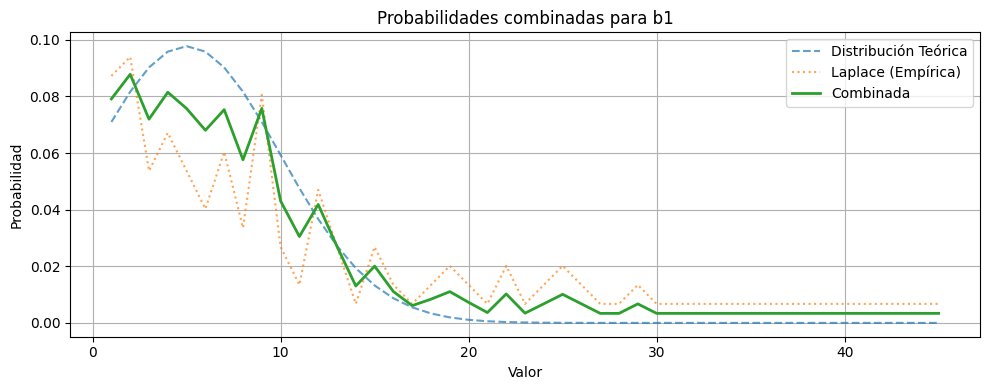

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  4: 0.0815
  1: 0.0791
  9: 0.0758
  5: 0.0757
  7: 0.0753
  3: 0.0720
  6: 0.0680
  8: 0.0576
  10: 0.0431


In [20]:
b1_vals = next_gen_analyze("b1", body_size=104)

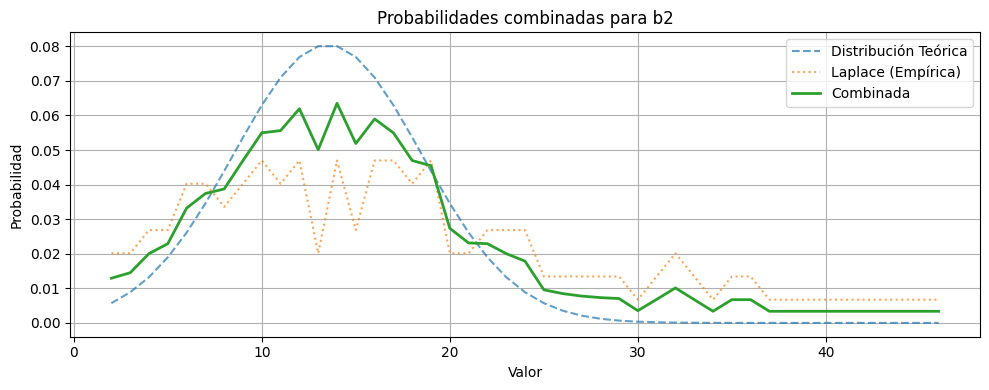

🎯 Siguientes valores más probables para b2:
  14: 0.0635
  12: 0.0619
  16: 0.0590
  11: 0.0556
  10: 0.0550
  17: 0.0550
  15: 0.0519
  13: 0.0501
  9: 0.0470
  18: 0.0470


In [21]:
b2_vals = next_gen_analyze("b2", body_size=104)

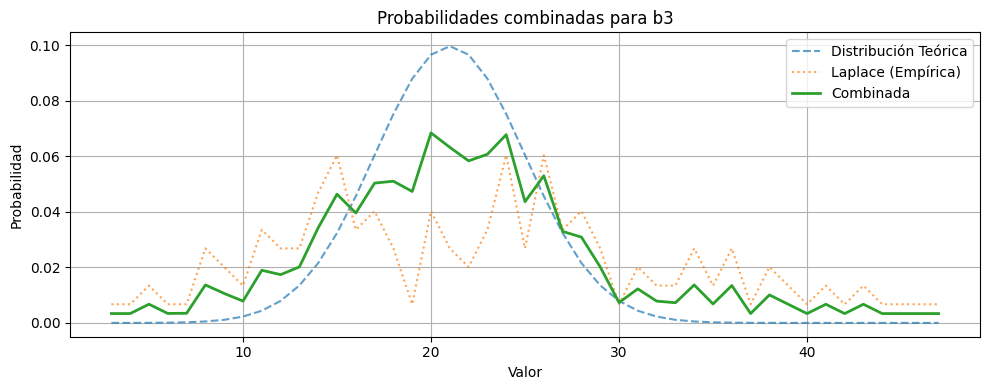

🎯 Siguientes valores más probables para b3:
  20: 0.0685
  24: 0.0678
  21: 0.0633
  23: 0.0608
  22: 0.0584
  26: 0.0530
  18: 0.0511
  17: 0.0504
  19: 0.0474
  15: 0.0464


In [22]:
b3_vals = next_gen_analyze("b3", body_size=104)

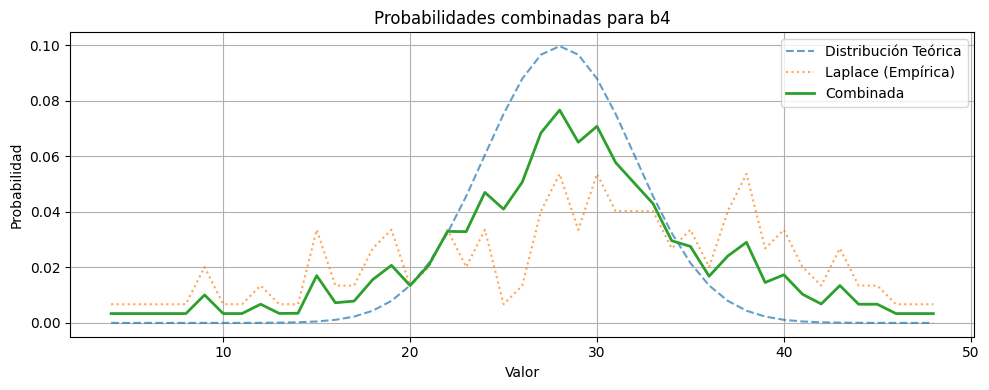

🎯 Siguientes valores más probables para b4:
  28: 0.0767
  30: 0.0709
  27: 0.0685
  29: 0.0651
  31: 0.0578
  26: 0.0507
  32: 0.0504
  24: 0.0470
  33: 0.0430
  25: 0.0410


In [23]:
b4_vals = next_gen_analyze("b4", body_size=104)

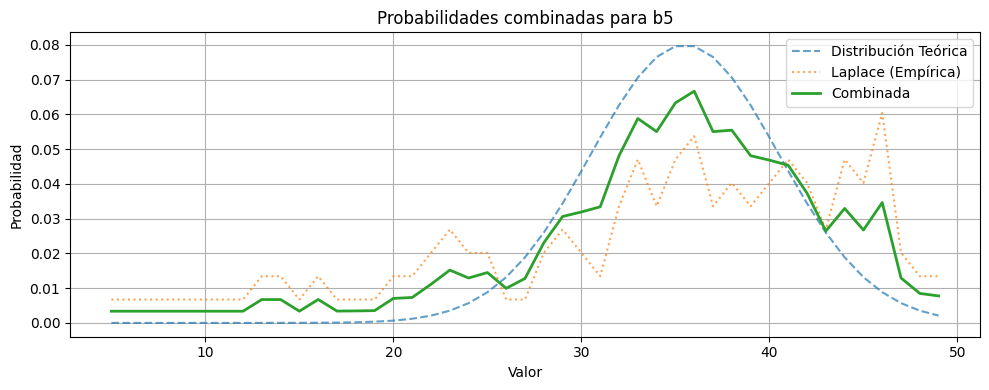

🎯 Siguientes valores más probables para b5:
  36: 0.0666
  35: 0.0633
  33: 0.0588
  38: 0.0554
  34: 0.0550
  37: 0.0550
  32: 0.0481
  39: 0.0481
  40: 0.0468
  41: 0.0453


In [24]:
b5_vals = next_gen_analyze("b5", body_size=104)

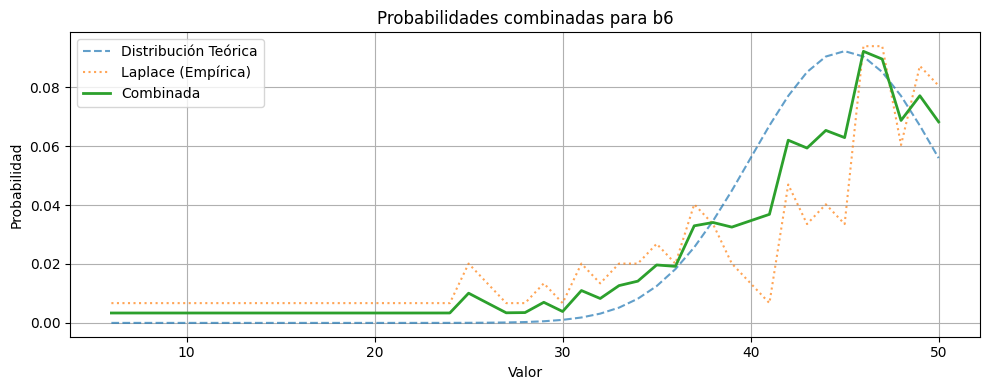

🎯 Siguientes valores más probables para b6:
  46: 0.0922
  47: 0.0896
  49: 0.0771
  48: 0.0687
  50: 0.0683
  44: 0.0654
  45: 0.0629
  42: 0.0620
  43: 0.0594
  41: 0.0369


In [25]:
b6_vals = next_gen_analyze("b6", body_size=104)